In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Loading data — this may take 30-60 seconds...")

cols_needed = [
    'fico_range_low',
    'fico_range_high', 
    'annual_inc',
    'dti',
    'loan_amnt',
    'int_rate',
    'grade',
    'sub_grade',
    'purpose',
    'loan_status',
    'issue_d',
    'term',
    'emp_length',
    'home_ownership',
    'addr_state'
]

df = pd.read_csv(
    'accepted_2007_to_2018Q4.csv',
    usecols=cols_needed,
    low_memory=False
)

print(f"Rows loaded: {len(df):,}")
print(f"Columns loaded: {len(df.columns)}")
print(f"\nColumn names and data types:")
print(df.dtypes)

Loading data — this may take 30-60 seconds...
Rows loaded: 2,260,701
Columns loaded: 15

Column names and data types:
loan_amnt          float64
term                object
int_rate           float64
grade               object
sub_grade           object
emp_length          object
home_ownership      object
annual_inc         float64
issue_d             object
loan_status         object
purpose             object
addr_state          object
dti                float64
fico_range_low     float64
fico_range_high    float64
dtype: object


In [3]:
print("SAMPLE OF RAW DATA")
print("=" * 60)
print(df.head(3).to_string())

print("\n\nKEY COLUMN DESCRIPTIONS")
print("=" * 60)
print("""
fico_range_low  : Lower bound of borrower's FICO score at origination
fico_range_high : Upper bound of borrower's FICO score at origination
annual_inc      : Self-reported annual income
dti             : Debt-to-income ratio (monthly debt / monthly income)
loan_amnt       : Loan amount requested and funded
int_rate        : Interest rate on the loan
grade           : LC assigned loan grade (A=lowest risk, G=highest risk)
loan_status     : Current status of the loan — THIS IS OUR OUTCOME VARIABLE
issue_d         : Month the loan was funded
term            : 36 or 60 months
""")

print("\nUNIQUE LOAN STATUSES (our outcome variable):")
print(df['loan_status'].value_counts())

SAMPLE OF RAW DATA
   loan_amnt        term  int_rate grade sub_grade emp_length home_ownership  annual_inc   issue_d loan_status             purpose addr_state    dti  fico_range_low  fico_range_high
0     3600.0   36 months     13.99     C        C4  10+ years       MORTGAGE     55000.0  Dec-2015  Fully Paid  debt_consolidation         PA   5.91           675.0            679.0
1    24700.0   36 months     11.99     C        C1  10+ years       MORTGAGE     65000.0  Dec-2015  Fully Paid      small_business         SD  16.06           715.0            719.0
2    20000.0   60 months     10.78     B        B4  10+ years       MORTGAGE     63000.0  Dec-2015  Fully Paid    home_improvement         IL  10.78           695.0            699.0


KEY COLUMN DESCRIPTIONS

fico_range_low  : Lower bound of borrower's FICO score at origination
fico_range_high : Upper bound of borrower's FICO score at origination
annual_inc      : Self-reported annual income
dti             : Debt-to-income ratio (

In [4]:
print("BEFORE CLEANING")
print(f"Total rows: {len(df):,}")
print(f"\nMissing values per column:")
print(df[cols_needed].isnull().sum())

BEFORE CLEANING
Total rows: 2,260,701

Missing values per column:
fico_range_low         33
fico_range_high        33
annual_inc             37
dti                  1744
loan_amnt              33
int_rate               33
grade                  33
sub_grade              33
purpose                33
loan_status            33
issue_d                33
term                   33
emp_length         146940
home_ownership         33
addr_state             33
dtype: int64


In [6]:
df['fico_score'] = ((df['fico_range_low'] + df['fico_range_high']) / 2)
df['fico_score'] = df['fico_score'].fillna(0).astype(int)

df['annual_inc'] = pd.to_numeric(df['annual_inc'], errors='coerce')
df['dti'] = pd.to_numeric(df['dti'], errors='coerce')

df_clean = df.dropna(subset=['fico_score', 'annual_inc', 'dti', 'loan_status'])

df_clean = df_clean[
    (df_clean['fico_score'] >= 300) & (df_clean['fico_score'] <= 850) &
    (df_clean['annual_inc'] >= 10000) & (df_clean['annual_inc'] <= 500000) &
    (df_clean['dti'] >= 0) & (df_clean['dti'] <= 65)
]

completed_statuses = [
    'Fully Paid',
    'Charged Off', 
    'Default',
    'Late (31-120 days)',
    'Late (16-30 days)',
    'Does not meet the credit policy. Status:Charged Off',
    'Does not meet the credit policy. Status:Fully Paid'
]

df_clean = df_clean[df_clean['loan_status'].isin(completed_statuses)]

def is_delinquent(status):
    bad_statuses = [
        'Charged Off',
        'Default', 
        'Late (31-120 days)',
        'Late (16-30 days)',
        'Does not meet the credit policy. Status:Charged Off'
    ]
    return 1 if status in bad_statuses else 0

df_clean['went_delinquent'] = df_clean['loan_status'].apply(is_delinquent)

print(f"\nAFTER CLEANING")
print(f"Total rows: {len(df_clean):,}")
print(f"\nOutcome distribution:")
print(df_clean['loan_status'].value_counts())
print(f"\nOverall delinquency rate: {df_clean['went_delinquent'].mean():.1%}")


AFTER CLEANING
Total rows: 1,369,254

Outcome distribution:
loan_status
Fully Paid                                             1073297
Charged Off                                             267656
Late (31-120 days)                                       21243
Late (16-30 days)                                         4311
Does not meet the credit policy. Status:Fully Paid        1955
Does not meet the credit policy. Status:Charged Off        752
Default                                                     40
Name: count, dtype: int64

Overall delinquency rate: 21.5%


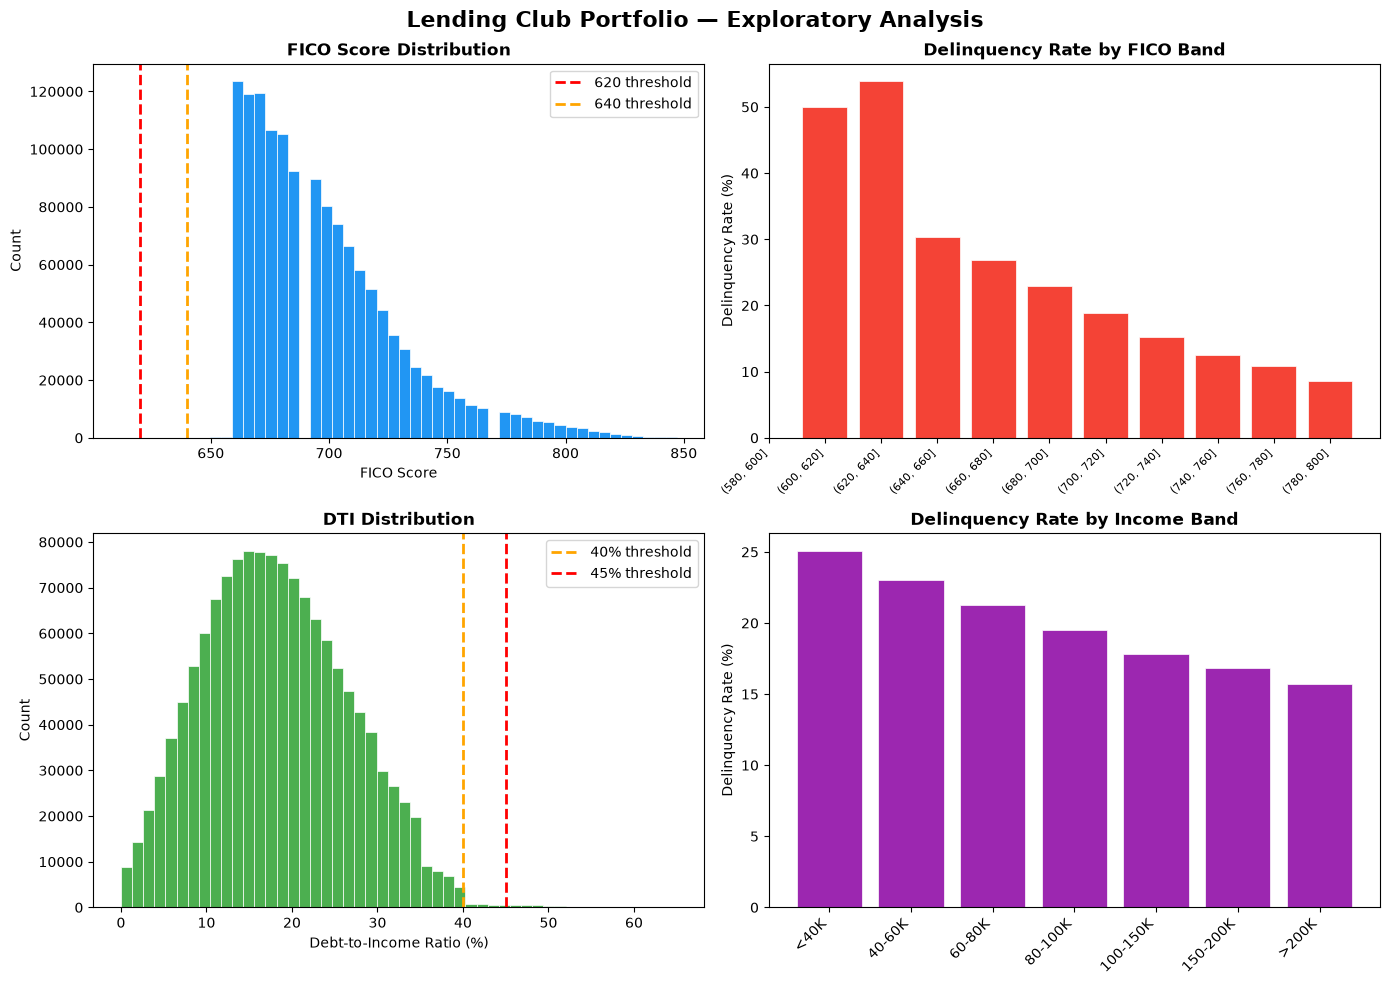


KEY INSIGHTS FROM EXPLORATORY ANALYSIS
Overall delinquency rate: 21.5%

Delinquency by FICO band:
fico_band
(580, 600]     NaN
(600, 620]    50.0
(620, 640]    53.8
(640, 660]    30.3
(660, 680]    26.8
(680, 700]    23.0
(700, 720]    18.8
(720, 740]    15.2
(740, 760]    12.5
(760, 780]    10.8
(780, 800]     8.6

Delinquency by income band:
income_band
(0, 40000]          25.1
(40000, 60000]      23.0
(60000, 80000]      21.2
(80000, 100000]     19.5
(100000, 150000]    17.8
(150000, 200000]    16.8
(200000, 500000]    15.7


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Lending Club Portfolio — Exploratory Analysis', 
             fontsize=16, fontweight='bold')

axes[0,0].hist(df_clean['fico_score'], bins=50, 
               color='#2196F3', edgecolor='white', linewidth=0.5)
axes[0,0].set_title('FICO Score Distribution', fontweight='bold')
axes[0,0].set_xlabel('FICO Score')
axes[0,0].set_ylabel('Count')
axes[0,0].axvline(x=620, color='red', linestyle='--', 
                   linewidth=2, label='620 threshold')
axes[0,0].axvline(x=640, color='orange', linestyle='--', 
                   linewidth=2, label='640 threshold')
axes[0,0].legend()

fico_bins = [580, 600, 620, 640, 660, 680, 700, 720, 740, 760, 780, 800]
df_clean['fico_band'] = pd.cut(df_clean['fico_score'], bins=fico_bins)
delinq_by_fico = df_clean.groupby('fico_band')['went_delinquent'].mean() * 100

axes[0,1].bar(range(len(delinq_by_fico)), delinq_by_fico.values,
              color='#F44336', edgecolor='white', linewidth=0.5)
axes[0,1].set_xticks(range(len(delinq_by_fico)))
axes[0,1].set_xticklabels([str(b) for b in delinq_by_fico.index], 
                            rotation=45, ha='right', fontsize=8)
axes[0,1].set_title('Delinquency Rate by FICO Band', fontweight='bold')
axes[0,1].set_ylabel('Delinquency Rate (%)')

axes[1,0].hist(df_clean['dti'], bins=50,
               color='#4CAF50', edgecolor='white', linewidth=0.5)
axes[1,0].set_title('DTI Distribution', fontweight='bold')
axes[1,0].set_xlabel('Debt-to-Income Ratio (%)')
axes[1,0].set_ylabel('Count')
axes[1,0].axvline(x=40, color='orange', linestyle='--', 
                   linewidth=2, label='40% threshold')
axes[1,0].axvline(x=45, color='red', linestyle='--', 
                   linewidth=2, label='45% threshold')
axes[1,0].legend()

income_bands = [0, 40000, 60000, 80000, 100000, 150000, 200000, 500000]
income_labels = ['<40K', '40-60K', '60-80K', '80-100K', 
                  '100-150K', '150-200K', '>200K']
df_clean['income_band'] = pd.cut(df_clean['annual_inc'], bins=income_bands)
delinq_by_income = df_clean.groupby('income_band')['went_delinquent'].mean() * 100

axes[1,1].bar(range(len(delinq_by_income)), delinq_by_income.values,
              color='#9C27B0', edgecolor='white', linewidth=0.5)
axes[1,1].set_xticks(range(len(delinq_by_income)))
axes[1,1].set_xticklabels(income_labels, rotation=45, ha='right')
axes[1,1].set_title('Delinquency Rate by Income Band', fontweight='bold')
axes[1,1].set_ylabel('Delinquency Rate (%)')

plt.tight_layout()
plt.savefig('exploratory_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKEY INSIGHTS FROM EXPLORATORY ANALYSIS")
print("=" * 50)
print(f"Overall delinquency rate: {df_clean['went_delinquent'].mean():.1%}")
print(f"\nDelinquency by FICO band:")
print(delinq_by_fico.round(1).to_string())
print(f"\nDelinquency by income band:")
print(delinq_by_income.round(1).to_string())

In [8]:
def champion_strategy(row):
    if (row['fico_score'] >= 620 and 
        row['annual_inc'] >= 40000 and 
        row['dti'] <= 45):
        return 'approved'
    return 'declined'

def challenger_strategy(row):
    if (row['fico_score'] >= 640 and 
        row['annual_inc'] >= 45000 and 
        row['dti'] <= 40):
        return 'approved'
    return 'declined'

print("Applying strategies — takes 30-60 seconds on real data...")

df_clean['champion_decision'] = df_clean.apply(champion_strategy, axis=1)
df_clean['challenger_decision'] = df_clean.apply(challenger_strategy, axis=1)

n_total = len(df_clean)
champion_approved = (df_clean['champion_decision'] == 'approved').sum()
challenger_approved = (df_clean['challenger_decision'] == 'approved').sum()

print(f"\nTotal loan population: {n_total:,}")
print(f"Champion approvals:    {champion_approved:,} ({champion_approved/n_total*100:.1f}%)")
print(f"Challenger approvals:  {challenger_approved:,} ({challenger_approved/n_total*100:.1f}%)")
print(f"Volume impact:         {(challenger_approved - champion_approved)/champion_approved*100:.1f}%")

Applying strategies — takes 30-60 seconds on real data...

Total loan population: 1,369,254
Champion approvals:    1,155,022 (84.4%)
Challenger approvals:  1,062,455 (77.6%)
Volume impact:         -8.0%


In [9]:
champion_portfolio = df_clean[df_clean['champion_decision'] == 'approved'].copy()
challenger_portfolio = df_clean[df_clean['challenger_decision'] == 'approved'].copy()

champion_delinq_rate = champion_portfolio['went_delinquent'].mean()
challenger_delinq_rate = challenger_portfolio['went_delinquent'].mean()

delinq_change = (challenger_delinq_rate - champion_delinq_rate) / champion_delinq_rate * 100

print("DELINQUENCY OUTCOMES — REAL LENDING CLUB DATA")
print("=" * 50)
print(f"\nChampion portfolio:")
print(f"  Loans approved:      {len(champion_portfolio):,}")
print(f"  Loans delinquent:    {champion_portfolio['went_delinquent'].sum():,}")
print(f"  Delinquency rate:    {champion_delinq_rate:.1%}")
print(f"\nChallenger portfolio:")
print(f"  Loans approved:      {len(challenger_portfolio):,}")
print(f"  Loans delinquent:    {challenger_portfolio['went_delinquent'].sum():,}")
print(f"  Delinquency rate:    {challenger_delinq_rate:.1%}")
print(f"\nDelinquency reduction: {delinq_change:.1f}%")
print(f"Volume impact:         {(challenger_approved - champion_approved)/champion_approved*100:.1f}%")

DELINQUENCY OUTCOMES — REAL LENDING CLUB DATA

Champion portfolio:
  Loans approved:      1,155,022
  Loans delinquent:    239,847
  Delinquency rate:    20.8%

Challenger portfolio:
  Loans approved:      1,062,455
  Loans delinquent:    217,614
  Delinquency rate:    20.5%

Delinquency reduction: -1.4%
Volume impact:         -8.0%


In [10]:
champion_delinq = champion_portfolio['went_delinquent'].values
challenger_delinq = challenger_portfolio['went_delinquent'].values

t_stat, p_value = stats.ttest_ind(
    champion_delinq, 
    challenger_delinq,
    equal_var=False
)

alpha = 0.05

champion_n = len(champion_delinq)
challenger_n = len(challenger_delinq)
champion_mean = champion_delinq.mean()
challenger_mean = challenger_delinq.mean()

champion_se = np.sqrt(champion_mean * (1 - champion_mean) / champion_n)
challenger_se = np.sqrt(challenger_mean * (1 - challenger_mean) / challenger_n)

champion_ci_lower = champion_mean - 1.96 * champion_se
champion_ci_upper = champion_mean + 1.96 * champion_se
challenger_ci_lower = challenger_mean - 1.96 * challenger_se
challenger_ci_upper = challenger_mean + 1.96 * challenger_se

delinq_change = (challenger_mean - champion_mean) / champion_mean * 100
volume_change = (challenger_approved - champion_approved) / champion_approved * 100

print("=" * 55)
print("STATISTICAL TEST RESULTS")
print("=" * 55)
print(f"\nChampion delinquency rate:  {champion_mean:.2%}")
print(f"  95% CI: [{champion_ci_lower:.2%}, {champion_ci_upper:.2%}]")
print(f"  Sample size: {champion_n:,}")
print(f"\nChallenger delinquency rate: {challenger_mean:.2%}")
print(f"  95% CI: [{challenger_ci_lower:.2%}, {challenger_ci_upper:.2%}]")
print(f"  Sample size: {challenger_n:,}")
print(f"\nDifference: {challenger_mean - champion_mean:.2%}")
print(f"Relative reduction: {delinq_change:.1f}%")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"\nResult: {'STATISTICALLY SIGNIFICANT' if p_value < alpha else 'NOT SIGNIFICANT'}")
print(f"(at 95% confidence level, alpha = {alpha})")

print(f"\n{'=' * 55}")
print("SUCCESS CRITERIA EVALUATION")
print('=' * 55)

delinq_target_met = delinq_change <= -15
volume_target_met = volume_change >= -10

print(f"\nCriteria 1 — Delinquency reduction ≥ 15%:")
print(f"  Target:  -15.0%")
print(f"  Actual:  {delinq_change:.1f}%")
print(f"  Result:  {'✓ MET' if delinq_target_met else '✗ NOT MET'}")

print(f"\nCriteria 2 — Volume impact within -10%:")
print(f"  Target:  -10.0%")
print(f"  Actual:  {volume_change:.1f}%")
print(f"  Result:  {'✓ MET' if volume_target_met else '✗ NOT MET'}")

print(f"\nStatistical significance:")
print(f"  Result:  {'✓ SIGNIFICANT' if p_value < alpha else '✗ NOT SIGNIFICANT'}")

print(f"\nOVERALL RECOMMENDATION:")
if p_value < alpha and delinq_target_met and volume_target_met:
    print("  → SCALE CHALLENGER STRATEGY")
elif p_value < alpha and not delinq_target_met:
    print("  → DO NOT SCALE — statistically significant but")
    print("    improvement too small to justify volume loss")
else:
    print("  → DO NOT SCALE — insufficient evidence")

STATISTICAL TEST RESULTS

Champion delinquency rate:  20.77%
  95% CI: [20.69%, 20.84%]
  Sample size: 1,155,022

Challenger delinquency rate: 20.48%
  95% CI: [20.41%, 20.56%]
  Sample size: 1,062,455

Difference: -0.28%
Relative reduction: -1.4%

T-statistic: 5.2111
P-value: 0.000000

Result: STATISTICALLY SIGNIFICANT
(at 95% confidence level, alpha = 0.05)

SUCCESS CRITERIA EVALUATION

Criteria 1 — Delinquency reduction ≥ 15%:
  Target:  -15.0%
  Actual:  -1.4%
  Result:  ✗ NOT MET

Criteria 2 — Volume impact within -10%:
  Target:  -10.0%
  Actual:  -8.0%
  Result:  ✓ MET

Statistical significance:
  Result:  ✓ SIGNIFICANT

OVERALL RECOMMENDATION:
  → DO NOT SCALE — statistically significant but
    improvement too small to justify volume loss


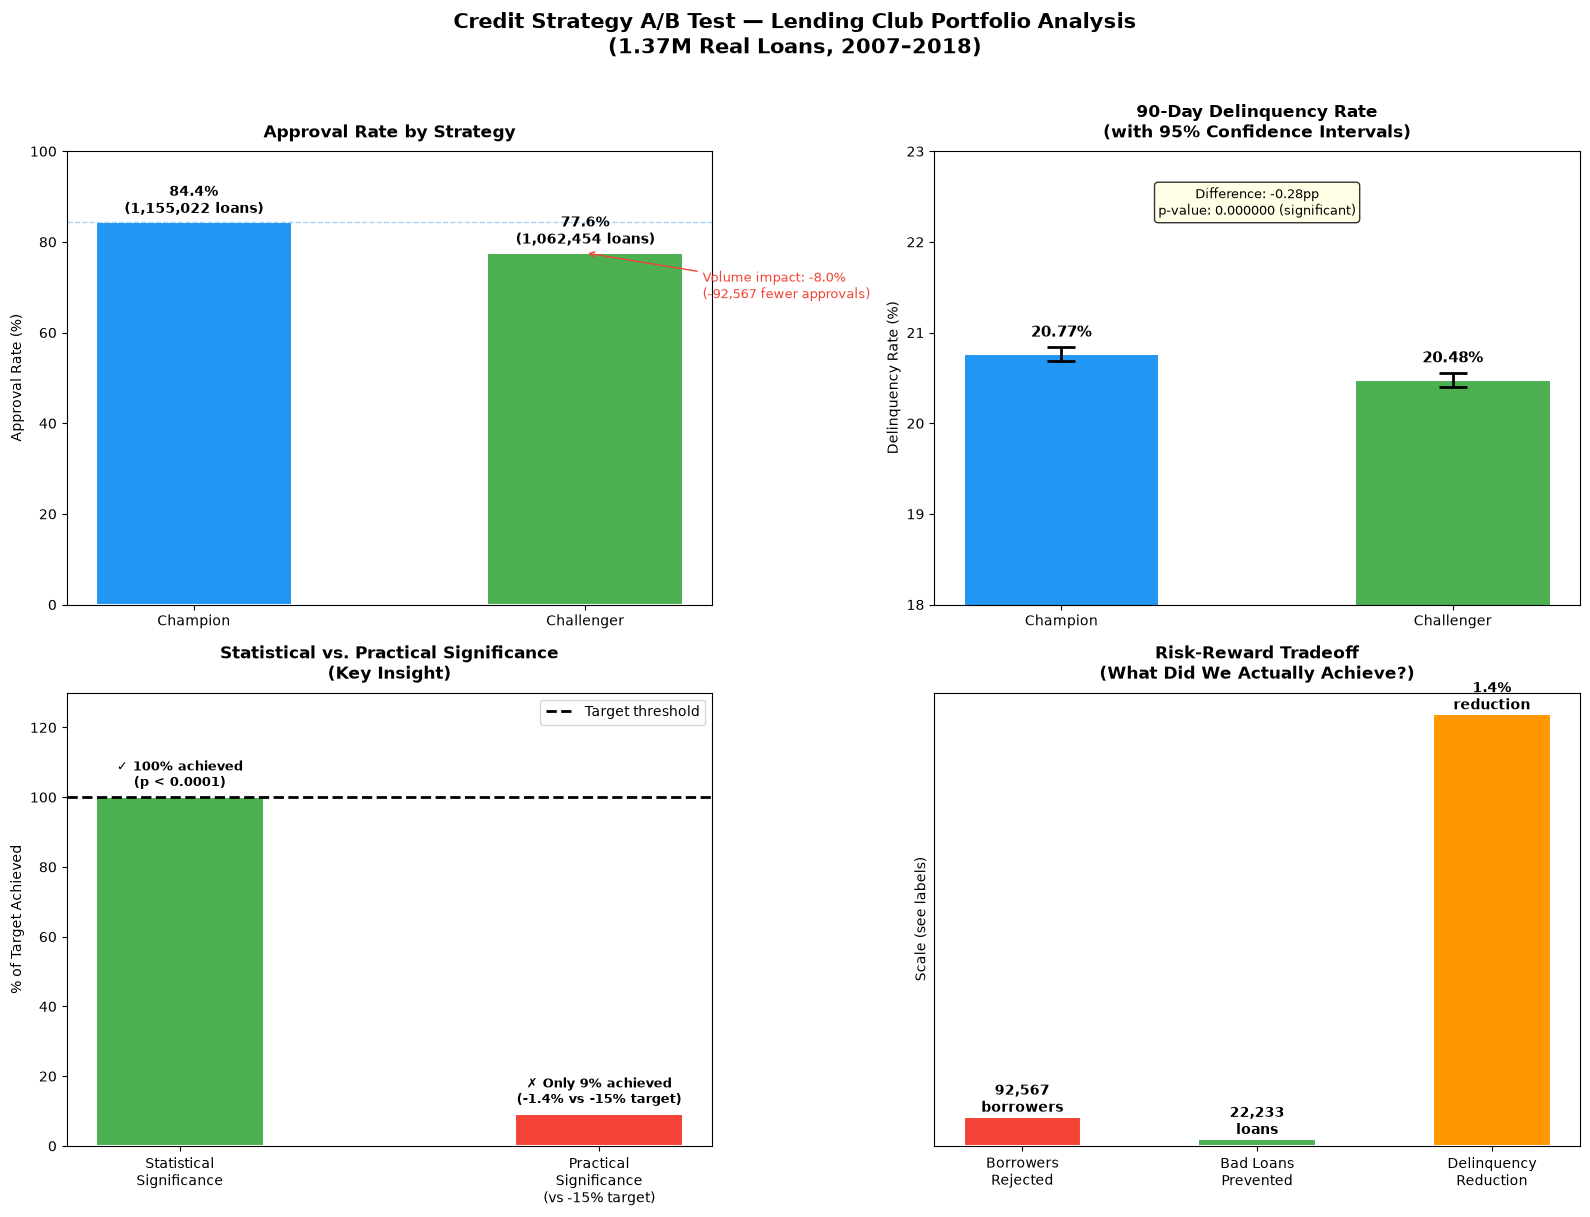

Chart saved as 'ab_test_results.png'


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Credit Strategy A/B Test — Lending Club Portfolio Analysis\n(1.37M Real Loans, 2007–2018)',
             fontsize=15, fontweight='bold', y=1.01)

colors = ['#2196F3', '#4CAF50']

# Chart 1: Approval Volume
approval_rates = [
    champion_approved/n_total*100,
    challenger_approved/n_total*100
]
bars1 = axes[0,0].bar(['Champion', 'Challenger'], 
                       approval_rates, 
                       color=colors, width=0.5,
                       edgecolor='white', linewidth=1.5)
axes[0,0].set_title('Approval Rate by Strategy', 
                     fontweight='bold', pad=10)
axes[0,0].set_ylabel('Approval Rate (%)')
axes[0,0].set_ylim(0, 100)
axes[0,0].axhline(y=approval_rates[0], color='#2196F3', 
                   linestyle='--', alpha=0.4, linewidth=1)
for bar, rate in zip(bars1, approval_rates):
    axes[0,0].text(bar.get_x() + bar.get_width()/2.,
                   bar.get_height() + 1,
                   f'{rate:.1f}%\n({int(rate/100 * n_total):,} loans)',
                   ha='center', va='bottom', 
                   fontweight='bold', fontsize=10)
axes[0,0].annotate(f'Volume impact: {(challenger_approved-champion_approved)/champion_approved*100:.1f}%\n({challenger_approved-champion_approved:,} fewer approvals)',
                    xy=(1, approval_rates[1]),
                    xytext=(1.3, approval_rates[1] - 10),
                    fontsize=9, color='#F44336',
                    arrowprops=dict(arrowstyle='->', color='#F44336'))

# Chart 2: Delinquency Rate with Confidence Intervals
delinq_rates = [champion_mean*100, challenger_mean*100]
ci_errors = [
    [champion_mean*100 - champion_ci_lower*100,
     challenger_mean*100 - challenger_ci_lower*100],
    [champion_ci_upper*100 - champion_mean*100,
     challenger_ci_upper*100 - challenger_mean*100]
]

bars2 = axes[0,1].bar(['Champion', 'Challenger'],
                       delinq_rates, color=colors,
                       width=0.5, edgecolor='white', linewidth=1.5)
axes[0,1].errorbar(['Champion', 'Challenger'],
                    delinq_rates,
                    yerr=ci_errors,
                    fmt='none', color='black',
                    capsize=10, linewidth=2, capthick=2)
axes[0,1].set_title('90-Day Delinquency Rate\n(with 95% Confidence Intervals)',
                     fontweight='bold', pad=10)
axes[0,1].set_ylabel('Delinquency Rate (%)')
axes[0,1].set_ylim(18, 23)
for bar, rate in zip(bars2, delinq_rates):
    axes[0,1].text(bar.get_x() + bar.get_width()/2.,
                   bar.get_height() + 0.15,
                   f'{rate:.2f}%',
                   ha='center', va='bottom',
                   fontweight='bold', fontsize=11)
axes[0,1].text(0.5, 22.3,
               f'Difference: {challenger_mean*100 - champion_mean*100:.2f}pp\np-value: {p_value:.6f} (significant)',
               ha='center', fontsize=9,
               bbox=dict(boxstyle='round,pad=0.3', 
                        facecolor='lightyellow', alpha=0.8))

# Chart 3: Statistical vs Practical Significance
categories = ['Statistical\nSignificance', 'Practical\nSignificance\n(vs -15% target)']
achieved = [100, abs(delinq_change/15*100)]
target = [100, 100]
colors_bar = ['#4CAF50', '#F44336']

bars3 = axes[1,0].bar(categories, achieved,
                       color=colors_bar, width=0.4,
                       edgecolor='white', linewidth=1.5)
axes[1,0].axhline(y=100, color='black', linewidth=2,
                   linestyle='--', label='Target threshold')
axes[1,0].set_title('Statistical vs. Practical Significance\n(Key Insight)',
                     fontweight='bold', pad=10)
axes[1,0].set_ylabel('% of Target Achieved')
axes[1,0].set_ylim(0, 130)
axes[1,0].legend()
for bar, val, label in zip(bars3, achieved, 
                             ['✓ 100% achieved\n(p < 0.0001)', 
                              f'✗ Only {abs(delinq_change/15*100):.0f}% achieved\n(-1.4% vs -15% target)']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2.,
                   bar.get_height() + 2,
                   label,
                   ha='center', va='bottom',
                   fontweight='bold', fontsize=9)

# Chart 4: Risk-Reward Summary
metrics = ['Borrowers\nRejected', 'Bad Loans\nPrevented', 'Delinquency\nReduction']
values = [
    abs(challenger_approved - champion_approved),
    abs(champion_portfolio['went_delinquent'].sum() - challenger_portfolio['went_delinquent'].sum()),
    abs(delinq_change)
]
labels = [f'{values[0]:,}\nborrowers', 
          f'{values[1]:,}\nloans',
          f'{values[2]:.1f}%\nreduction']
bar_colors = ['#F44336', '#4CAF50', '#FF9800']

bars4 = axes[1,1].bar(metrics, 
                       [values[0]/1000, values[1]/1000, values[2]*1000],
                       color=bar_colors, width=0.5,
                       edgecolor='white', linewidth=1.5)
axes[1,1].set_title('Risk-Reward Tradeoff\n(What Did We Actually Achieve?)',
                     fontweight='bold', pad=10)
axes[1,1].set_ylabel('Scale (see labels)')
axes[1,1].set_yticks([])
for bar, label in zip(bars4, labels):
    axes[1,1].text(bar.get_x() + bar.get_width()/2.,
                   bar.get_height() + 0.5,
                   label,
                   ha='center', va='bottom',
                   fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 'ab_test_results.png'")

In [12]:
print("=" * 65)
print("EXECUTIVE SUMMARY")
print("CREDIT STRATEGY CHAMPION/CHALLENGER TEST")
print("Lending Club Consumer Loan Portfolio | 2007–2018")
print("=" * 65)

print(f"""
OBJECTIVE
─────────────────────────────────────────────────────────────
Test whether tightening approval criteria reduces 90-day 
delinquency while maintaining acceptable approval volume.

  Champion:   FICO ≥ 620 | Income ≥ $40K | DTI ≤ 45%
  Challenger: FICO ≥ 640 | Income ≥ $45K | DTI ≤ 40%

  Success criteria:
    • Delinquency reduction ≥ 15%
    • Approval volume impact within -10%

POPULATION
─────────────────────────────────────────────────────────────
  Total loans analyzed:      {n_total:>12,}
  Champion approvals:        {champion_approved:>12,}  ({champion_approved/n_total:.1%})
  Challenger approvals:      {challenger_approved:>12,}  ({challenger_approved/n_total:.1%})
  Borrowers excluded by
  challenger criteria:       {champion_approved - challenger_approved:>12,}

RESULTS
─────────────────────────────────────────────────────────────
  Champion delinquency rate:   {champion_mean:.2%}
    95% CI: [{champion_ci_lower:.2%}, {champion_ci_upper:.2%}]

  Challenger delinquency rate: {challenger_mean:.2%}
    95% CI: [{challenger_ci_lower:.2%}, {challenger_ci_upper:.2%}]

  Absolute difference:         {abs(challenger_mean - champion_mean):.2%}
  Relative reduction:          {delinq_change:.1f}%
  Volume impact:               {volume_change:.1f}%

  T-statistic:                 {t_stat:.4f}
  P-value:                     {p_value:.6f}
  Statistical significance:    YES (p < 0.0001)

SUCCESS CRITERIA EVALUATION
─────────────────────────────────────────────────────────────
  Delinquency reduction ≥ 15%:    ✗ NOT MET  (-1.4% actual)
  Volume impact within -10%:      ✓ MET      (-8.0% actual)
  Statistically significant:      ✓ YES      (p < 0.0001)

KEY INSIGHT — STATISTICAL VS. PRACTICAL SIGNIFICANCE
─────────────────────────────────────────────────────────────
  The challenger strategy is statistically superior — with
  1.37M loans, even a 0.28pp difference is detectable with
  near-certainty (p < 0.0001).

  However, statistical significance does not equal business
  value. To achieve a 0.28pp delinquency improvement, the
  challenger rejects 92,567 creditworthy borrowers — a 
  poor risk-reward tradeoff that fails our 15% target by
  a factor of 10x.

  This is a critical distinction in credit strategy:
  large portfolios will make almost any difference 
  "significant." Business decisions require BOTH statistical
  rigor AND practical impact thresholds.

RECOMMENDATION
─────────────────────────────────────────────────────────────
  DO NOT SCALE THE CHALLENGER STRATEGY.

  Rationale:
  1. Delinquency improvement (-1.4%) is commercially 
     insufficient — falls 93% short of the -15% target
  2. Rejecting 92,567 borrowers generates meaningful
     revenue loss that the risk improvement does not offset
  3. The criteria changes are too incremental — FICO +20pts
     and DTI -5pts do not materially shift the risk profile
     of the approved population

NEXT STEPS
─────────────────────────────────────────────────────────────
  1. Redesign challenger with more aggressive segmentation —
     consider targeting the 620-640 FICO band specifically
     rather than applying uniform criteria shifts
  2. Incorporate loan purpose and employment length as
     additional risk signals — both available in this dataset
  3. Run vintage analysis to understand loss emergence timing
     by FICO band before finalizing new criteria
  4. Evaluate fair lending implications of any criteria
     changes before production deployment
  5. Present findings to Credit Policy Committee with
     revised test design proposal
""")

print("=" * 65)
print("Analysis conducted using 1.37M real Lending Club loans")
print("Tools: Python | pandas | scipy | matplotlib")
print("Data: Lending Club public dataset (2007–2018)")
print("=" * 65)

EXECUTIVE SUMMARY
CREDIT STRATEGY CHAMPION/CHALLENGER TEST
Lending Club Consumer Loan Portfolio | 2007–2018

OBJECTIVE
─────────────────────────────────────────────────────────────
Test whether tightening approval criteria reduces 90-day 
delinquency while maintaining acceptable approval volume.

  Champion:   FICO ≥ 620 | Income ≥ $40K | DTI ≤ 45%
  Challenger: FICO ≥ 640 | Income ≥ $45K | DTI ≤ 40%

  Success criteria:
    • Delinquency reduction ≥ 15%
    • Approval volume impact within -10%

POPULATION
─────────────────────────────────────────────────────────────
  Total loans analyzed:         1,369,254
  Champion approvals:           1,155,022  (84.4%)
  Challenger approvals:         1,062,455  (77.6%)
  Borrowers excluded by
  challenger criteria:             92,567

RESULTS
─────────────────────────────────────────────────────────────
  Champion delinquency rate:   20.77%
    95% CI: [20.69%, 20.84%]

  Challenger delinquency rate: 20.48%
    95% CI: [20.41%, 20.56%]

  Absolut